FINANCIAL MARKET ANALYZER
-------------------------

Choose time period:
1. 1 month
2. 3 months
3. 6 months
4. 1 year
5. 5 years

Enter choice: 6

Enter 3 assets to compare.
Asset 1: Reliance industries limited
Asset 2: HDFC Bank Limited
Asset 3: Infosys limited
✓ Reliance industries limited → RELIANCE.NS
✓ HDFC Bank Limited → HDB
✓ Infosys limited → INFY


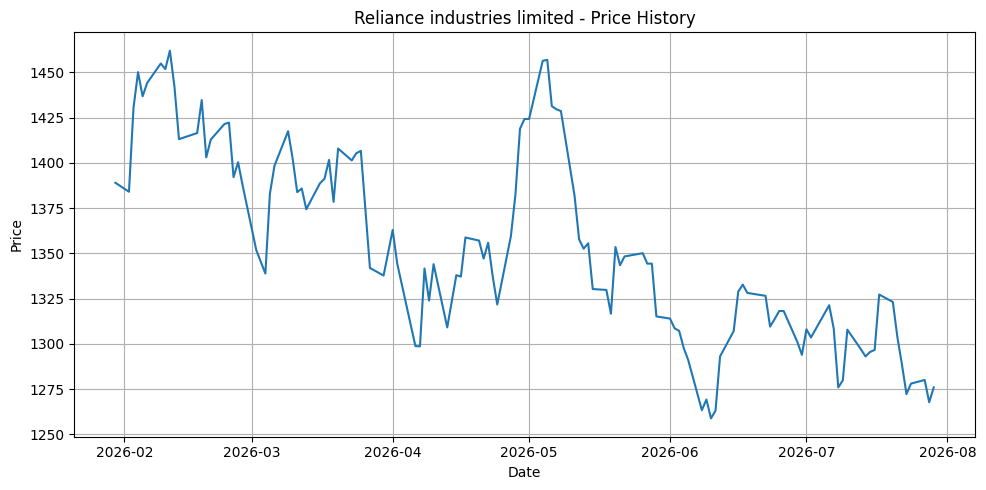

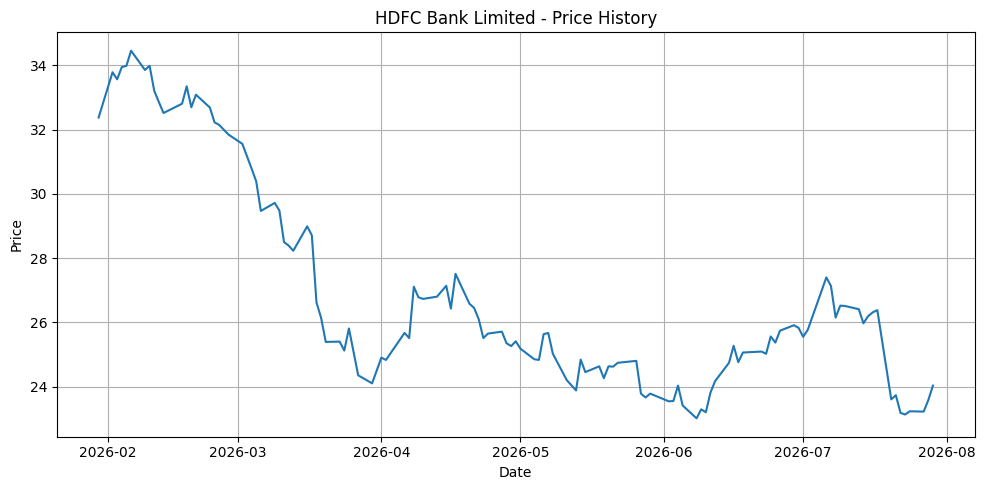

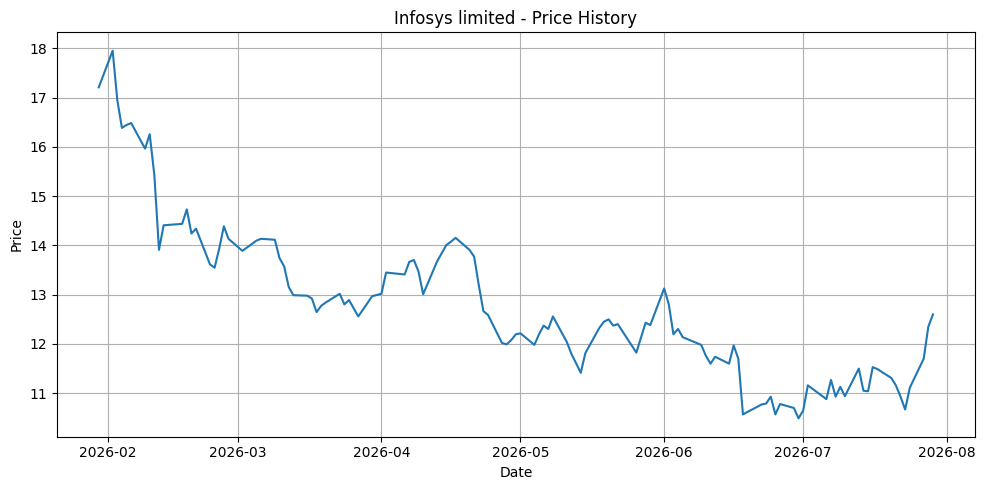

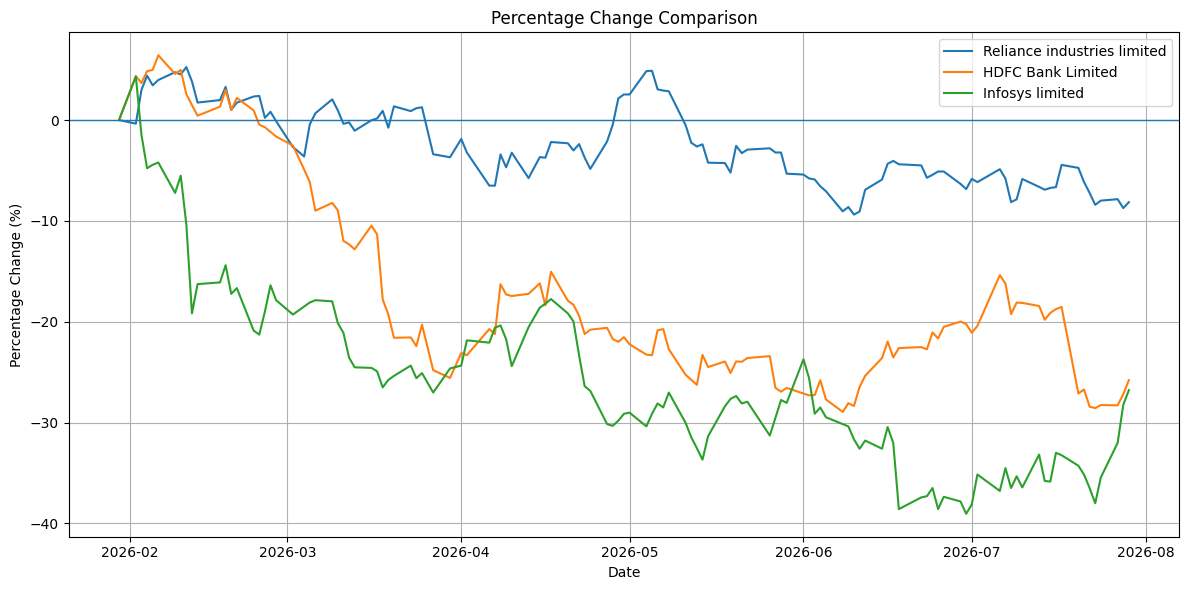


FINAL PERFORMANCE
Reliance industries limited: -8.14%
HDFC Bank Limited: -25.79%
Infosys limited: -26.78%

CORRELATION MATRIX
                             Reliance industries limited  HDFC Bank Limited  \
Reliance industries limited                         1.00               0.28   
HDFC Bank Limited                                   0.28               1.00   
Infosys limited                                    -0.01               0.20   

                             Infosys limited  
Reliance industries limited            -0.01  
HDFC Bank Limited                       0.20  
Infosys limited                         1.00  


In [1]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Choose time period
# -----------------------------

periods = {
    "1": "1mo",
    "2": "3mo",
    "3": "6mo",
    "4": "1y",
    "5": "5y"
}

print("FINANCIAL MARKET ANALYZER")
print("-------------------------")

print("\nChoose time period:")
print("1. 1 month")
print("2. 3 months")
print("3. 6 months")
print("4. 1 year")
print("5. 5 years")

choice = input("\nEnter choice: ")
period = periods.get(choice, "6mo")

# -----------------------------
# Enter assets
# -----------------------------

print("\nEnter 3 assets to compare.")

asset1 = input("Asset 1: ")
asset2 = input("Asset 2: ")
asset3 = input("Asset 3: ")

assets = [asset1, asset2, asset3]

# -----------------------------
# Find ticker
# -----------------------------

def find_ticker(name):

    search = yf.Search(name)
    quotes = search.quotes

    if not quotes:
        return None

    return quotes[0]["symbol"]


# -----------------------------
# Find selected assets
# -----------------------------

tickers = {}

for asset in assets:

    ticker = find_ticker(asset)

    if ticker:
        tickers[asset] = ticker
        print(f"✓ {asset} → {ticker}")
    else:
        print(f"✗ Could not find {asset}")


# -----------------------------
# Download data
# -----------------------------

data = {}

for name, ticker in tickers.items():

    prices = yf.download(
        ticker,
        period=period,
        auto_adjust=True,
        progress=False
    )["Close"].squeeze()

    data[name] = prices


data = pd.DataFrame(data).dropna()

# -----------------------------
# Individual price charts
# -----------------------------

for asset in data.columns:

    plt.figure(figsize=(10, 5))

    plt.plot(data.index, data[asset])

    plt.title(f"{asset} - Price History")
    plt.xlabel("Date")
    plt.ylabel("Price")

    plt.grid(True)
    plt.tight_layout()
    plt.show()


# -----------------------------
# Percentage change
# -----------------------------

percentage_change = (data / data.iloc[0] - 1) * 100

plt.figure(figsize=(12, 6))

for asset in percentage_change.columns:

    plt.plot(
        percentage_change.index,
        percentage_change[asset],
        label=asset
    )

plt.axhline(0, linewidth=1)

plt.title("Percentage Change Comparison")
plt.xlabel("Date")
plt.ylabel("Percentage Change (%)")

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# -----------------------------
# Final performance
# -----------------------------

print("\nFINAL PERFORMANCE")

for asset in percentage_change.columns:

    change = percentage_change[asset].iloc[-1]

    print(f"{asset}: {change:.2f}%")


# -----------------------------
# Correlation
# -----------------------------

correlation = data.pct_change().corr()

print("\nCORRELATION MATRIX")
print(correlation.round(2))